In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path

import torch

# Модель

## Загрузка данных

In [2]:
sys.path.append(os.path.dirname(os.getcwd()))
from preprocess.classes.pipe_preprocess import PreprocessingPipeline
from model.classes.ueba_datasets import UEBADataset
from model.classes.evaluator import Evaluator
from model.classes.builder_dataset import DatasetBuilder
from model.classes.trainer import Trainer
from model.classes.model import AutoEncoder

In [3]:
file_path = Path.cwd().parent / 'data' / 'anomaly.csv'

anomaly = pd.read_csv(file_path)

In [4]:
file_path = Path.cwd().parent / 'data' / 'dataset.csv'

normal = pd.read_csv(file_path)

In [5]:
pipeline = PreprocessingPipeline()

data_builder = DatasetBuilder(
    pipeline=pipeline,
    dataset_cls=UEBADataset
)

In [6]:
train_data = data_builder.build(normal)

d:\App\Anaconda\envs\pytorch_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


In [7]:
anomal_dataset = data_builder.transform(anomaly)
anomal_loader = data_builder.transform(anomaly, batch_size=256)

## Подготовка модели

In [8]:
model = AutoEncoder(
    input_dim=train_data['X_train'].shape[1],
    hidden_dims=[64, 16]
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

trainer = Trainer(
    model,
    optimizer,
)

In [9]:
history = trainer.fit(
    train_loader=train_data['train_loader'],
    val_loader=train_data['val_loader'],
    epochs=75
)

Epoch 001 | train=8.379431 | val=8.025380
Epoch 002 | train=1.044064 | val=4.254169
Epoch 003 | train=0.593980 | val=3.843525
Epoch 004 | train=0.496170 | val=3.440357
Epoch 005 | train=0.367402 | val=2.843222
Epoch 006 | train=0.300781 | val=2.514844
Epoch 007 | train=0.256022 | val=2.168953
Epoch 008 | train=0.210389 | val=1.732599
Epoch 009 | train=0.163838 | val=1.369236
Epoch 010 | train=0.118193 | val=1.194856
Epoch 011 | train=0.091514 | val=1.051255
Epoch 012 | train=0.074584 | val=0.937652
Epoch 013 | train=0.066268 | val=0.867984
Epoch 014 | train=0.062212 | val=0.828601
Epoch 015 | train=0.060035 | val=0.754291
Epoch 016 | train=0.055250 | val=0.712868
Epoch 017 | train=0.050677 | val=0.705289
Epoch 018 | train=0.049220 | val=0.639083
Epoch 019 | train=0.045449 | val=0.597590
Epoch 020 | train=0.043301 | val=0.586150
Epoch 021 | train=0.041535 | val=0.530086
Epoch 022 | train=0.040282 | val=0.511588
Epoch 023 | train=0.040409 | val=0.472954
Epoch 024 | train=0.039626 | val=0

In [10]:
evaluator = Evaluator(model)

# Анализ порога

## Распределение

In [11]:
def show(eval: Evaluator, loaders: dict[str, any]):

    eps = 1e-8

    plt.figure(figsize=(10,6))

    stats = {}

    for name, loader in loaders.items():

        loader_error = eval.reconstruction_errors(loader)

        sns.kdeplot(np.log10(loader_error + eps), label=name, fill=True)

        stats[name] = pd.Series(loader_error).describe()

    plt.xlabel("log10(ошибки восстановления)")
    plt.grid(alpha=0.3)
    plt.legend()

    stats = pd.DataFrame(stats).T.round(4)

    display(stats)

,count,mean,std,min,25%,50%,75%,max
train,13796.0,0.0082,0.0817,0.0000,0.0002,0.0005,0.0026,8.8969
val,3451.0,0.3371,2.3735,0.0002,0.1177,0.1452,0.1845,64.0530
anom,209.0,6.4504,14.7410,0.0841,0.1490,0.2390,4.7161,74.9538


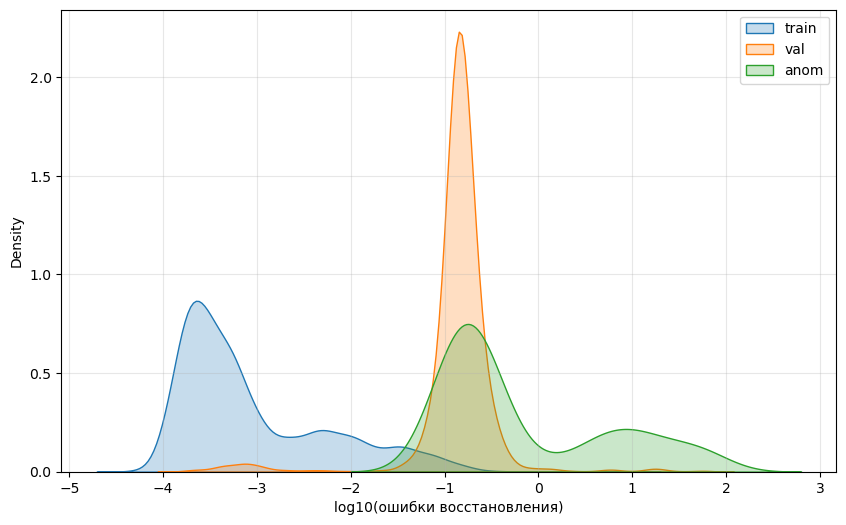

In [12]:
show(
    eval=evaluator,
    loaders={
        'train': train_data['train_loader'],
        'val': train_data['val_loader'],
        'anom': anomal_loader
    }
)

График плотности ошибок восстановления показывает, что train выборка хорошо отделяется от аномальных наблюдений. Это свидетельствует о том, что автоэнкодер успешно моделирует нормальное поведение системы и допускает существенно большие ошибки восстановления на аномальных объектах

Вместе с тем распределения ошибок для val и anom выборок частично перекрываются. Такое поведение объясняется тем, что валидационная выборка соответствует новому временному интервалу работы пользователя, который отсутствовал при обучении модели. Поэтому часть нормальных состояний также восстанавливается с повышенной ошибкой. В свою очередь, аномальные объекты в среднем характеризуются еще большей ошибкой реконструкции, вследствие чего их распределение смещено вправо относительно валидационной выборки.

Наличие области пересечения означает, что не существует един-ого порога, который позволил бы полностью разделить нормальные и аномальные объекты без ошибок классификации. Следовательно, задача выбора порога сводится к поиску компромисса между FP и FN

In [13]:
def show_feature_contribution(
    evaluator,
    anomaly_loader,
    feature_names,
    top=None,
):
    contribution = pd.DataFrame(
        evaluator.explain(next(iter(anomaly_loader)))["feature_error"],
        columns=feature_names
    ).mean()

    contribution = (
        contribution
        .div(contribution.sum())
        .mul(100)
        .sort_values(ascending=False)
    )

    if top:
        contribution = contribution.head(top)

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=contribution.values,
        y=contribution.index,
        color="steelblue"
    )

    plt.xlabel("Вклад в общую ошибку")
    plt.ylabel("")
    plt.title("Признаки, определяющие аномалию")
    plt.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

    display(contribution.round(2).to_frame("Вклад"))

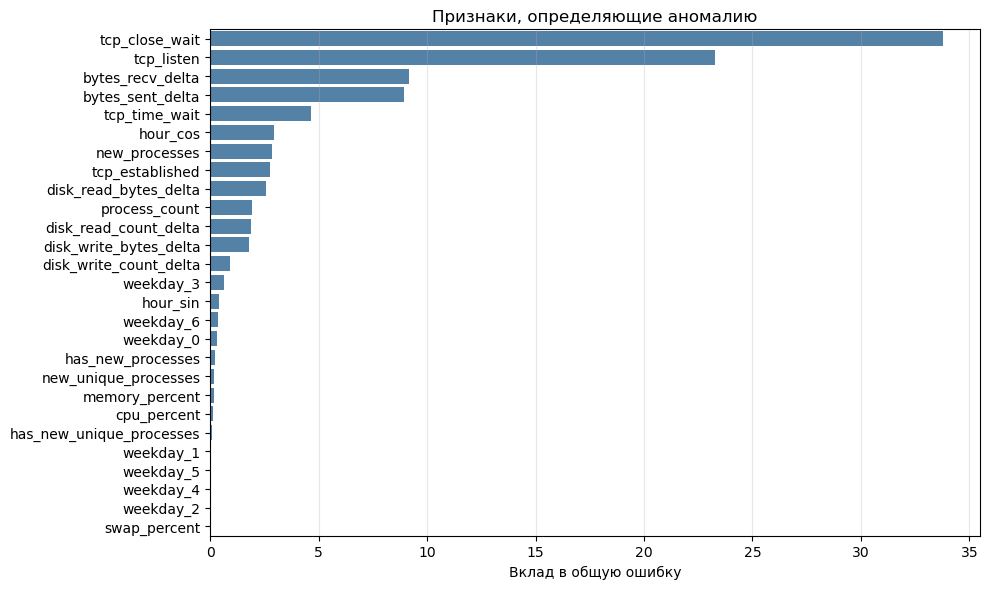

,Вклад
tcp_close_wait,33.799999
tcp_listen,23.280001
bytes_recv_delta,9.180000
bytes_sent_delta,8.940000
tcp_time_wait,4.670000
hour_cos,2.930000
new_processes,2.850000
tcp_established,2.730000
disk_read_bytes_delta,2.550000
process_count,1.950000


In [14]:
show_feature_contribution(
    evaluator=evaluator,
    anomaly_loader=anomal_loader,
    feature_names=train_data["X_train"].columns,
)

In [17]:
def show_worst_anomaly(
    evaluator,
    loader,
    feature_names,
):
    exp = evaluator.explain(next(iter(loader)))

    idx = np.argmax(exp["total_error"])

    result = pd.DataFrame({
        "original": exp["original"][idx],
        "reconstruction": exp["reconstruction"][idx],
        "feature_error": exp["feature_error"][idx]
    }, index=feature_names)

    result = result.sort_values(
        "feature_error",
        ascending=False
    )

    display(result.round(3))

    plt.figure(figsize=(12, 5))

    plot = (
        result
        .head(10)
        .reset_index()
        .rename(columns={"index": "feature"})
        .melt(
            id_vars="feature",
            value_vars=["original", "reconstruction"],
            var_name="type",
            value_name="value"
        )
    )

    sns.barplot(
        data=plot,
        x="value",
        y="feature",
        hue="type"
    )

    plt.title("Самая выраженная аномалия")
    plt.xlabel("")
    plt.ylabel("")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

,original,reconstruction,feature_error
tcp_close_wait,68.000,36.467999,994.252014
tcp_listen,1.000,21.011999,400.489014
bytes_recv_delta,10.894,22.271999,129.472000
hour_cos,0.966,-10.173000,124.083000
disk_read_bytes_delta,0.000,9.350000,87.422997
tcp_time_wait,45.000,35.880001,83.175003
new_processes,0.000,8.965000,80.375000
disk_read_count_delta,0.000,7.225000,52.195999
disk_write_bytes_delta,1.625,7.849000,38.730999
hour_sin,0.259,3.147000,8.342000


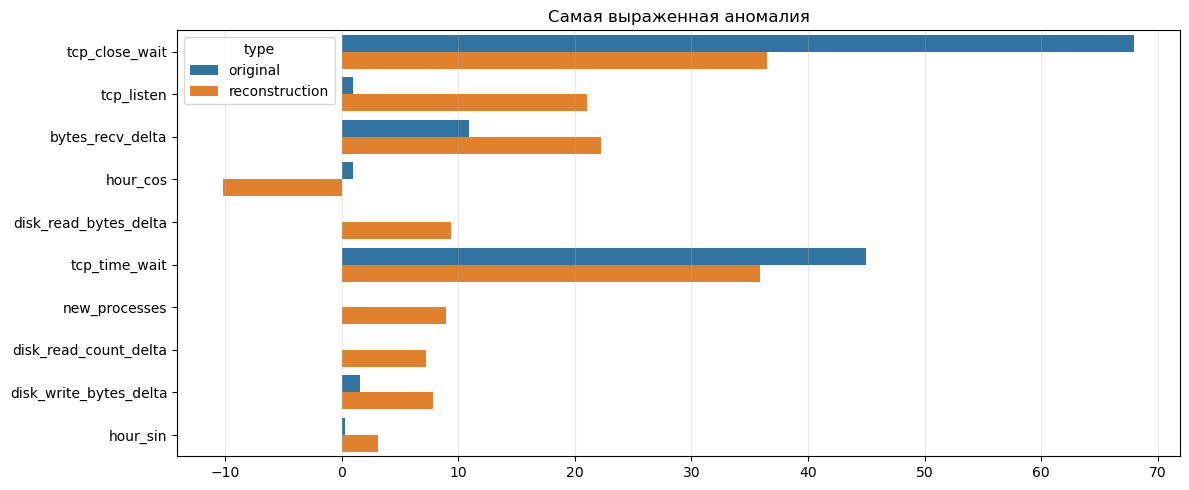

In [18]:
show_worst_anomaly(
    evaluator,
    anomal_loader,
    feature_names=train_data['X_train'].columns
)

В аномальной выборке наибольший вклад в ошибку реконструкции вносят признаки, характеризующие состояние TCP-соединений, процессы и нагрузка отправки и принятия битов. Совокупно данные группы признаков объясняют большую часть ошибки реконструкции, что позволяет рассматривать их как основные факторы, определяющие аномальное поведение объекта в __данном датасете__

Исходя из этого, далее рассмотрим эволюцию наиболее информативных признаков во времени, сравнив их поведение на нормальных и аномальных данных, и отметим области наблюдений, которые модель классифицирует как аномальные.

Поскольку окончательное решение принимается на основе порога ошибки реконструкции, в качестве первого приближения рассмотрим несколько вариантов порога, заданных через различные значения перцентилей распределения ошибки реконструкции. Это позволит оценить влияние выбора порога на количество обнаруживаемых аномалий и определить области, в которых модель начинает фиксировать отклонения.

## Детекция аномалий. Рассмотрение эволюции признаков train и val выборки

### Порогая детекция

Рассмотрим приние аномалии самым простым правилом - перцениль некоторого уровня.

In [19]:
def show_threshold(
    evaluator,
    normal,
    anomaly,
    val_loader,
    anomaly_loader,
    features,
    percentile=99,
):

    val_errors = evaluator.reconstruction_errors(val_loader)
    anom_errors = evaluator.reconstruction_errors(anomaly_loader)

    threshold = np.percentile(val_errors, percentile)

    anomaly_mask = anom_errors > threshold

    fig, ax = plt.subplots(
        len(features),
        2,
        figsize=(15, 3 * len(features)),
        sharex="col"
    )

    for i, feature in enumerate(features):

        sns.lineplot(
            x=np.arange(len(normal)),
            y=normal[feature],
            ax=ax[i, 0],
            color="steelblue"
        )

        ax[i, 0].set_title(f"Нормальный - {feature}")
        ax[i, 0].grid(alpha=0.3)


        sns.lineplot(
            x=np.arange(len(anomaly)),
            y=anomaly[feature],
            ax=ax[i, 1],
            color="black"
        )

        idx = np.where(anomaly_mask)[0]

        for j in idx:
            ax[i, 1].axvspan(
                j - 0.5,
                j + 0.5,
                color="red",
                alpha=0.25
            )

        ax[i, 1].set_title(f"аномалия - {feature}")
        ax[i, 1].grid(alpha=0.3)

    plt.suptitle(f"порог = {percentile} перцентиля")
    plt.tight_layout()
    plt.show()

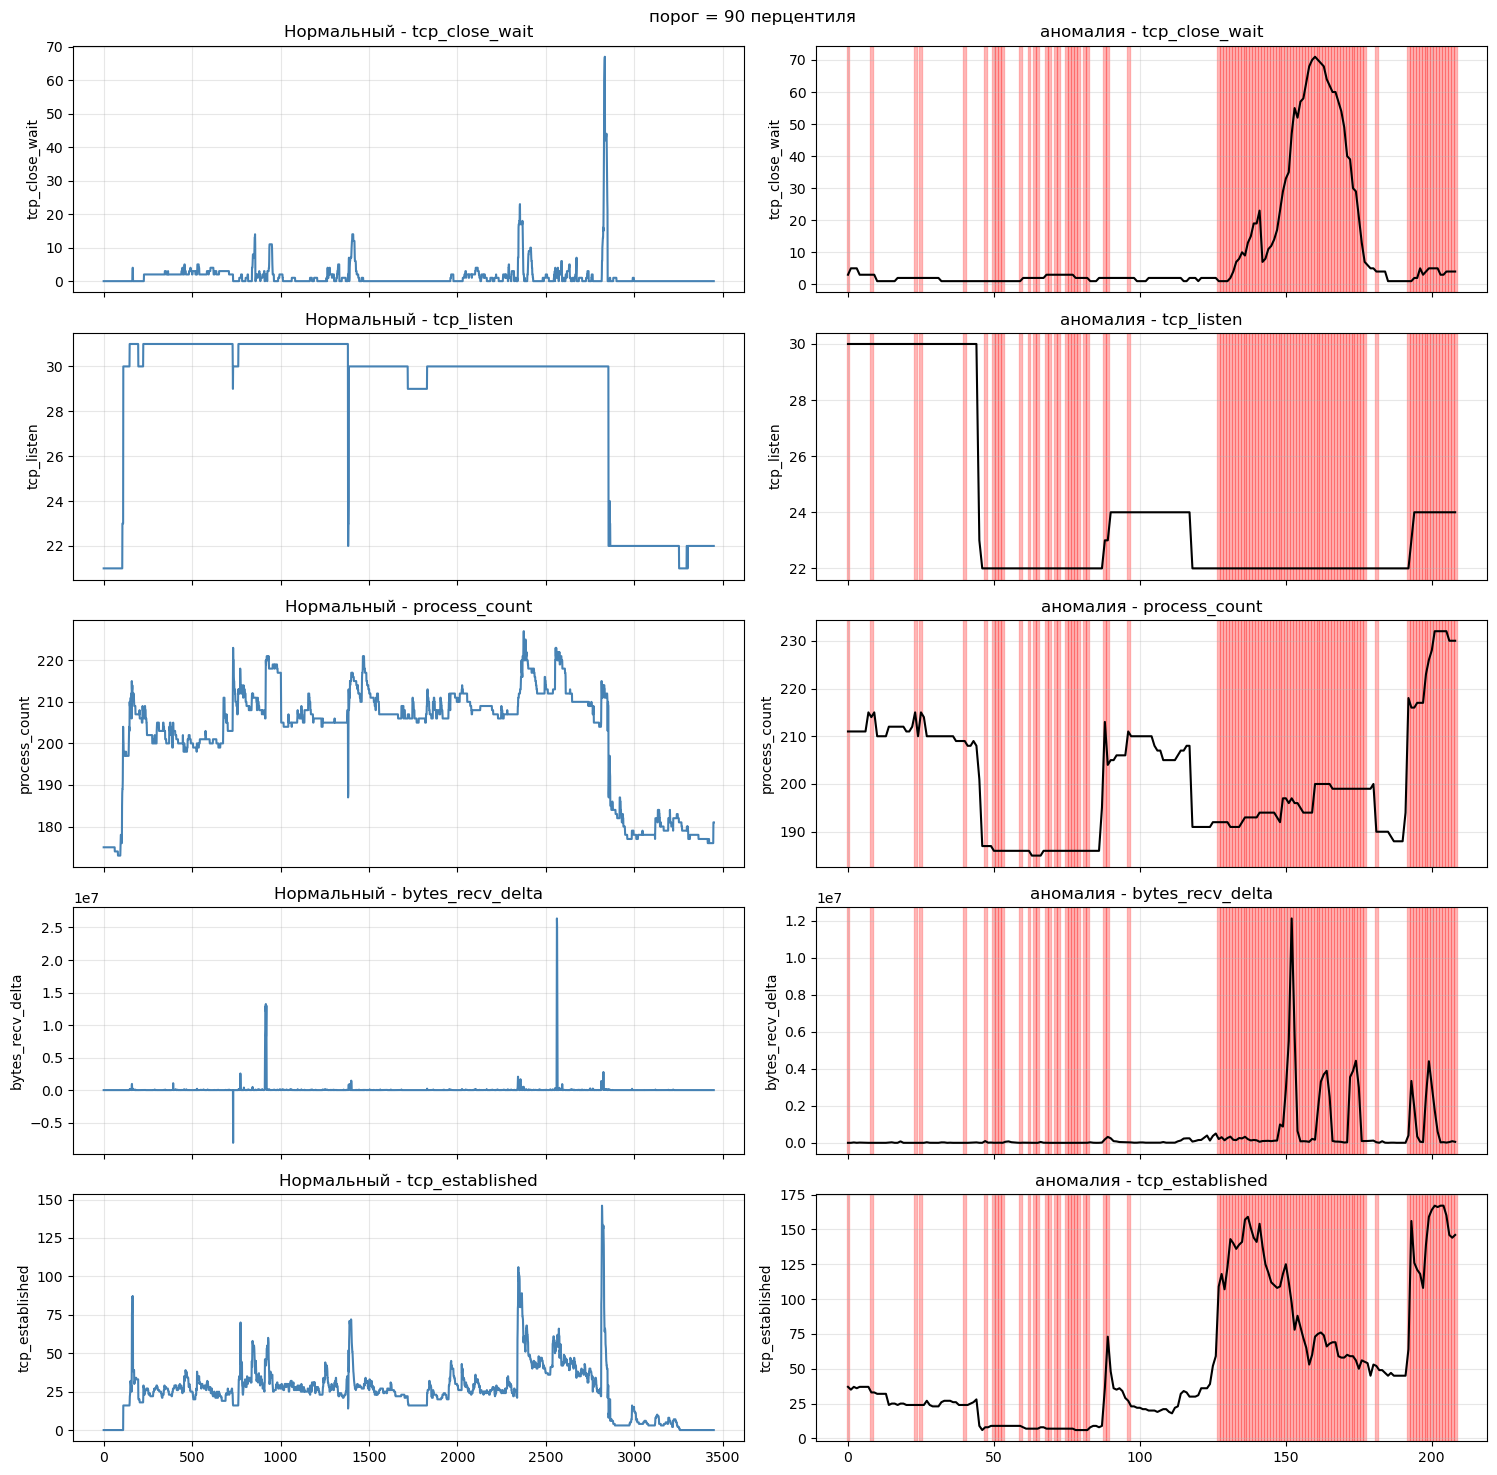

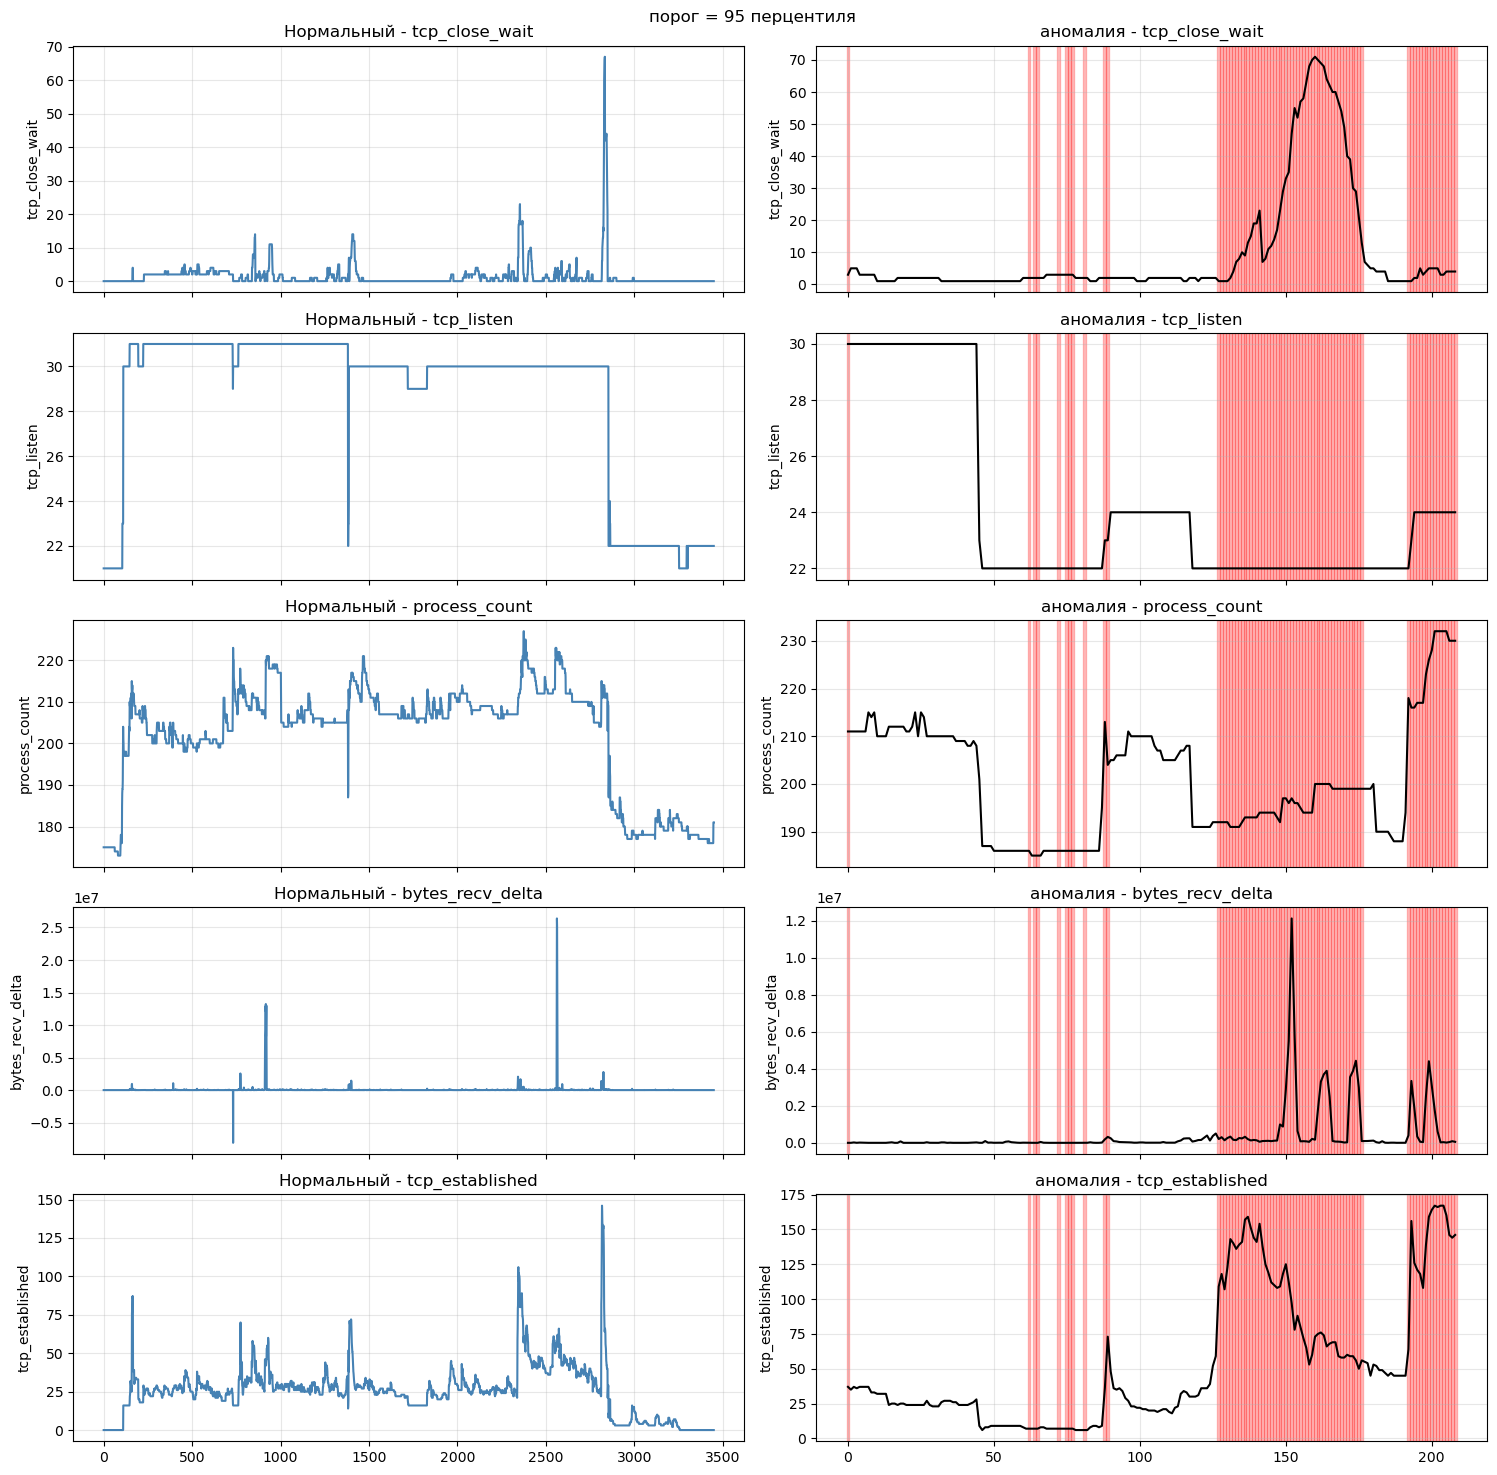

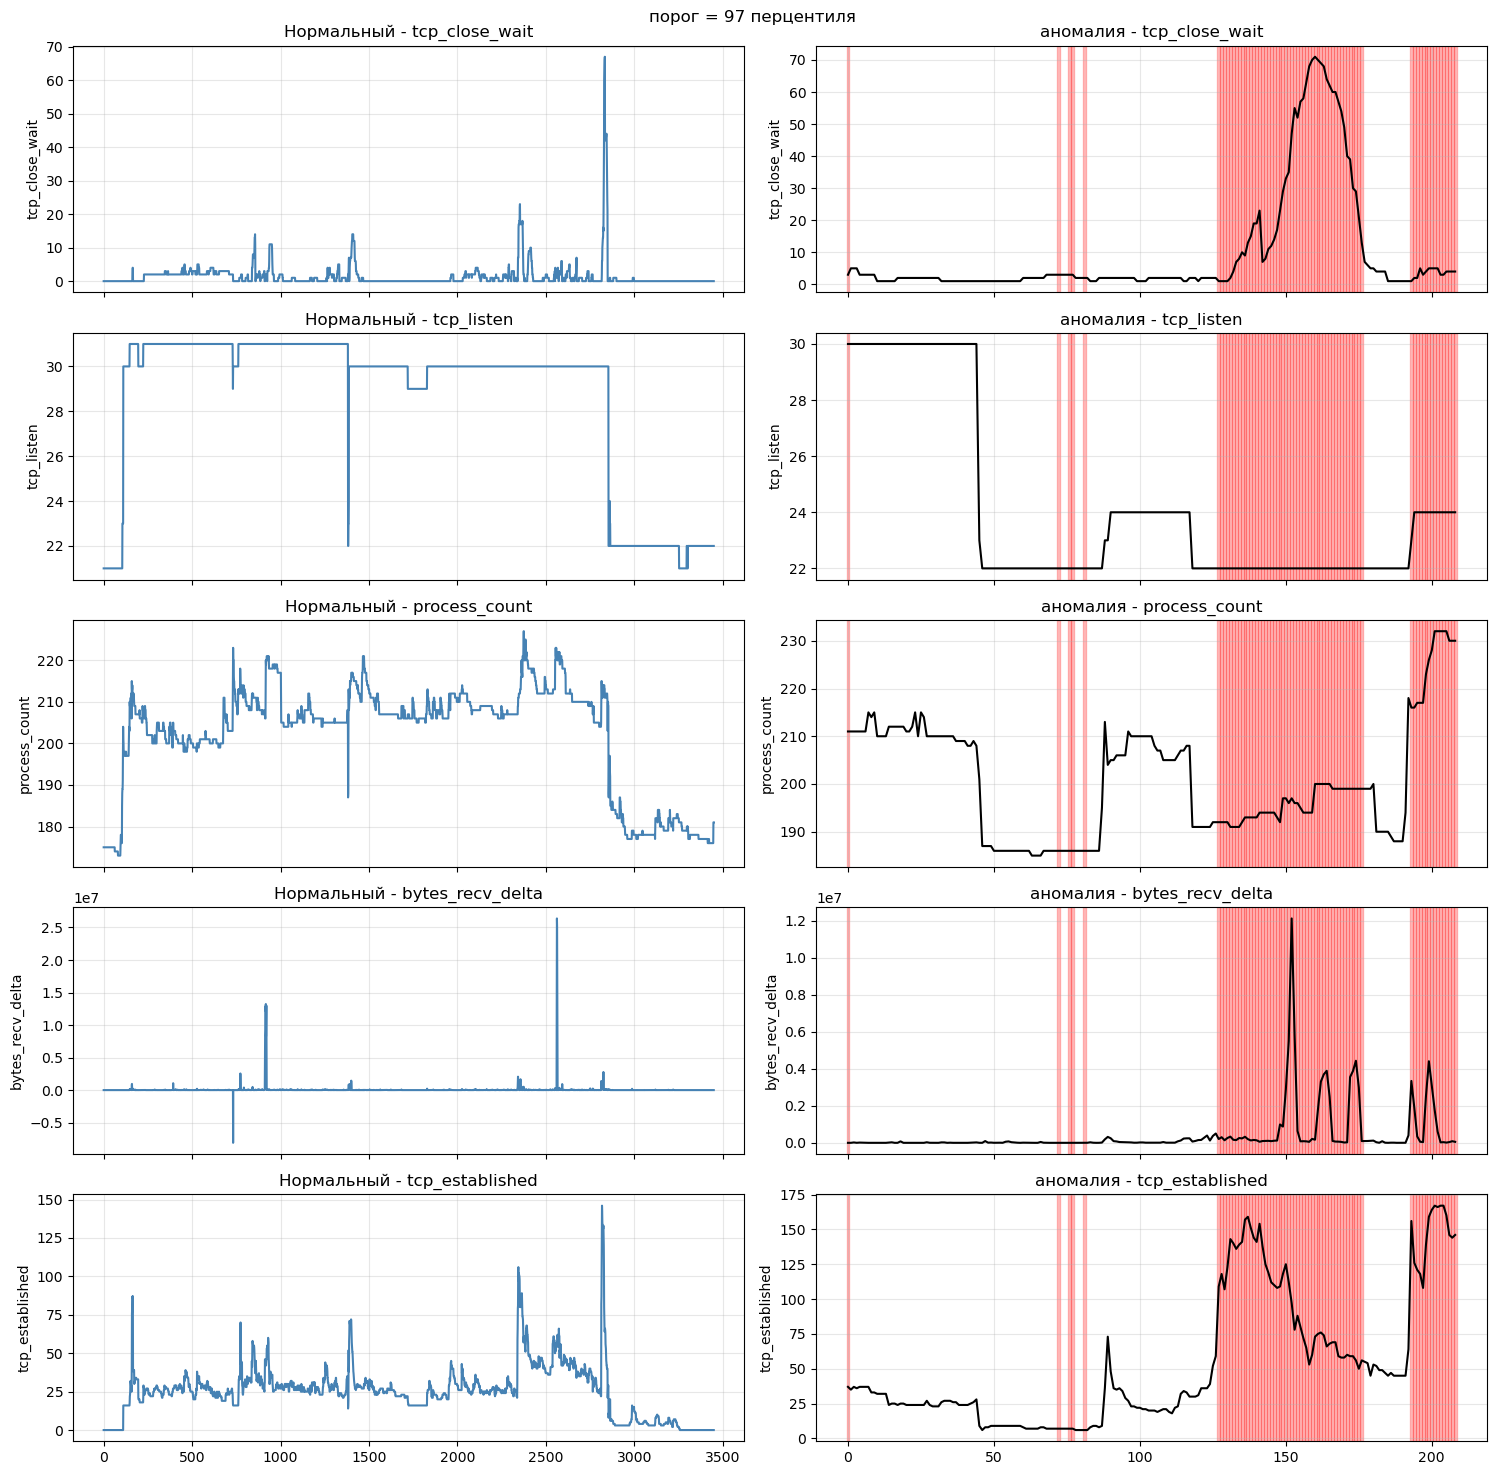

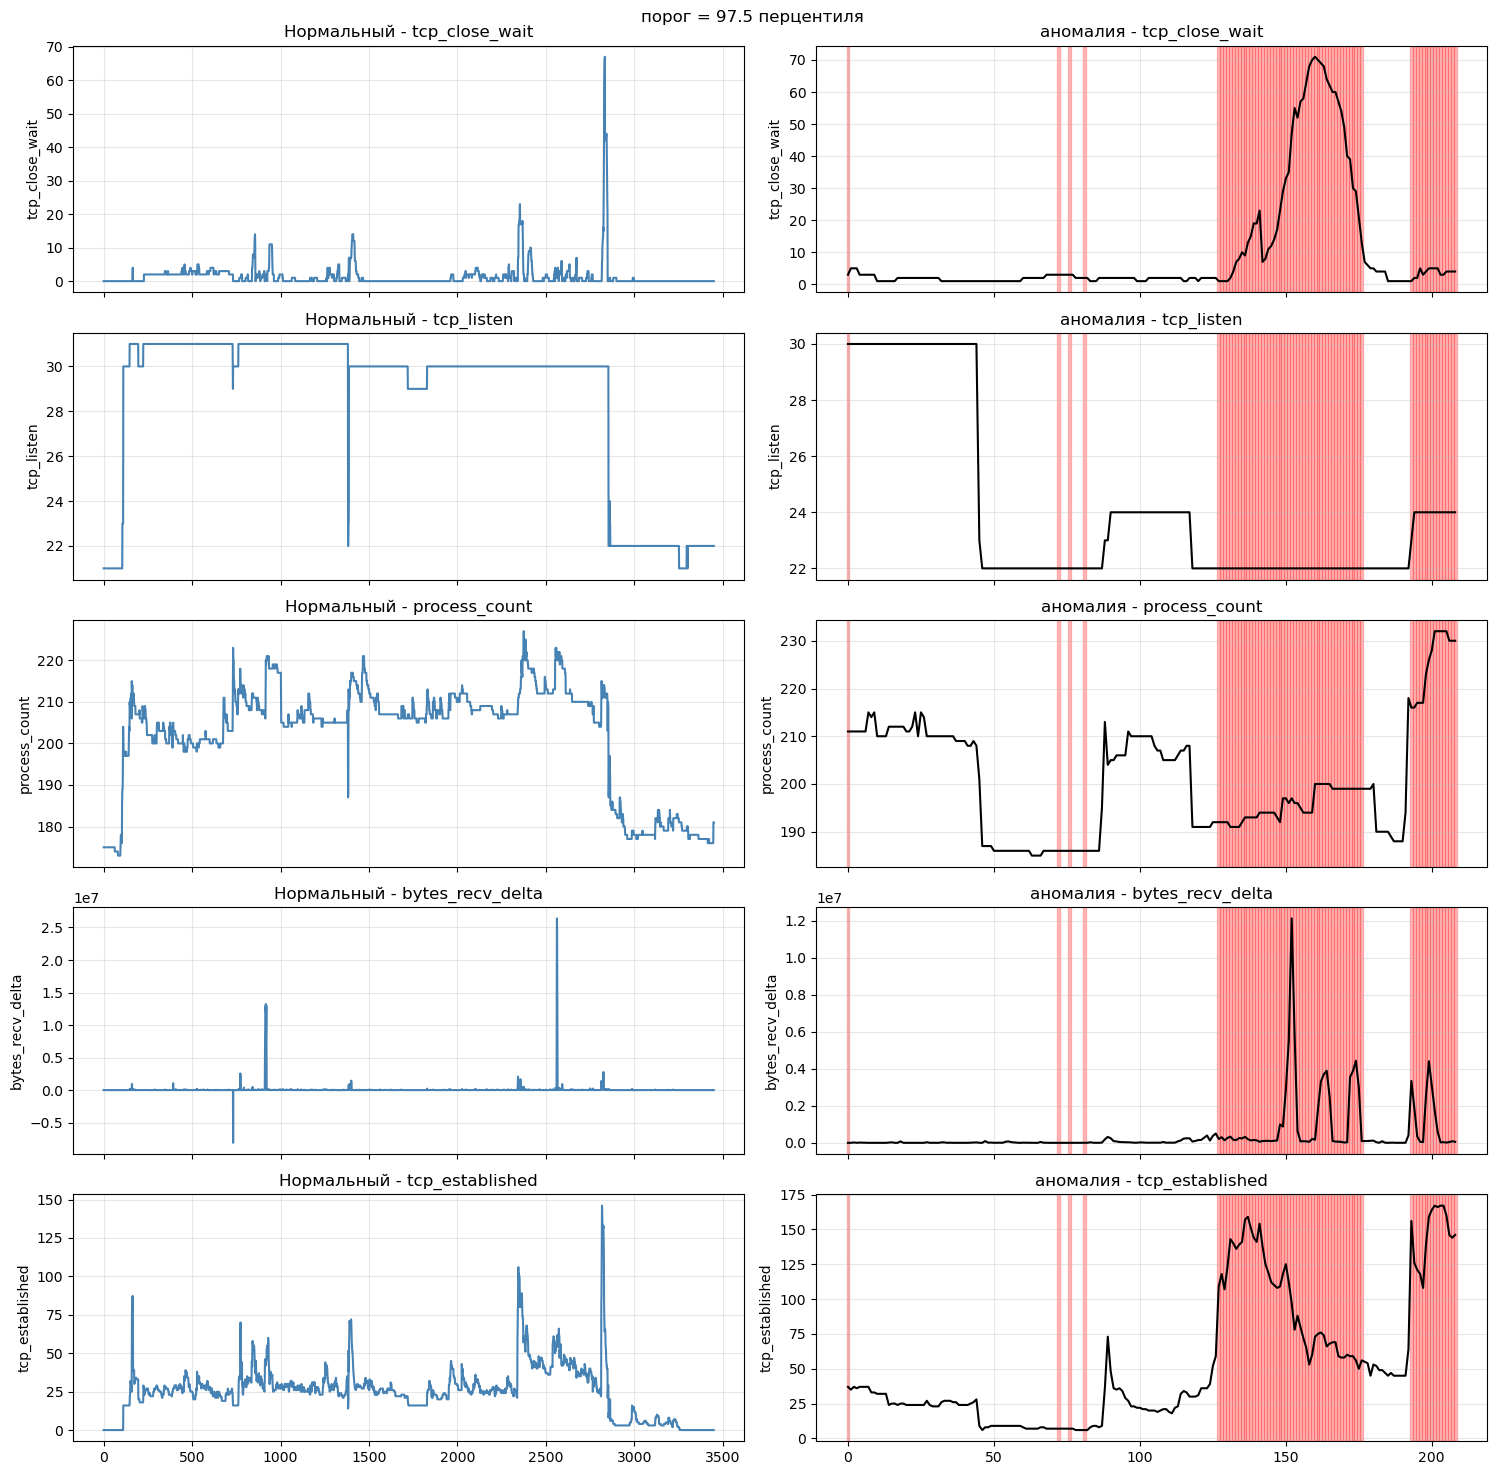

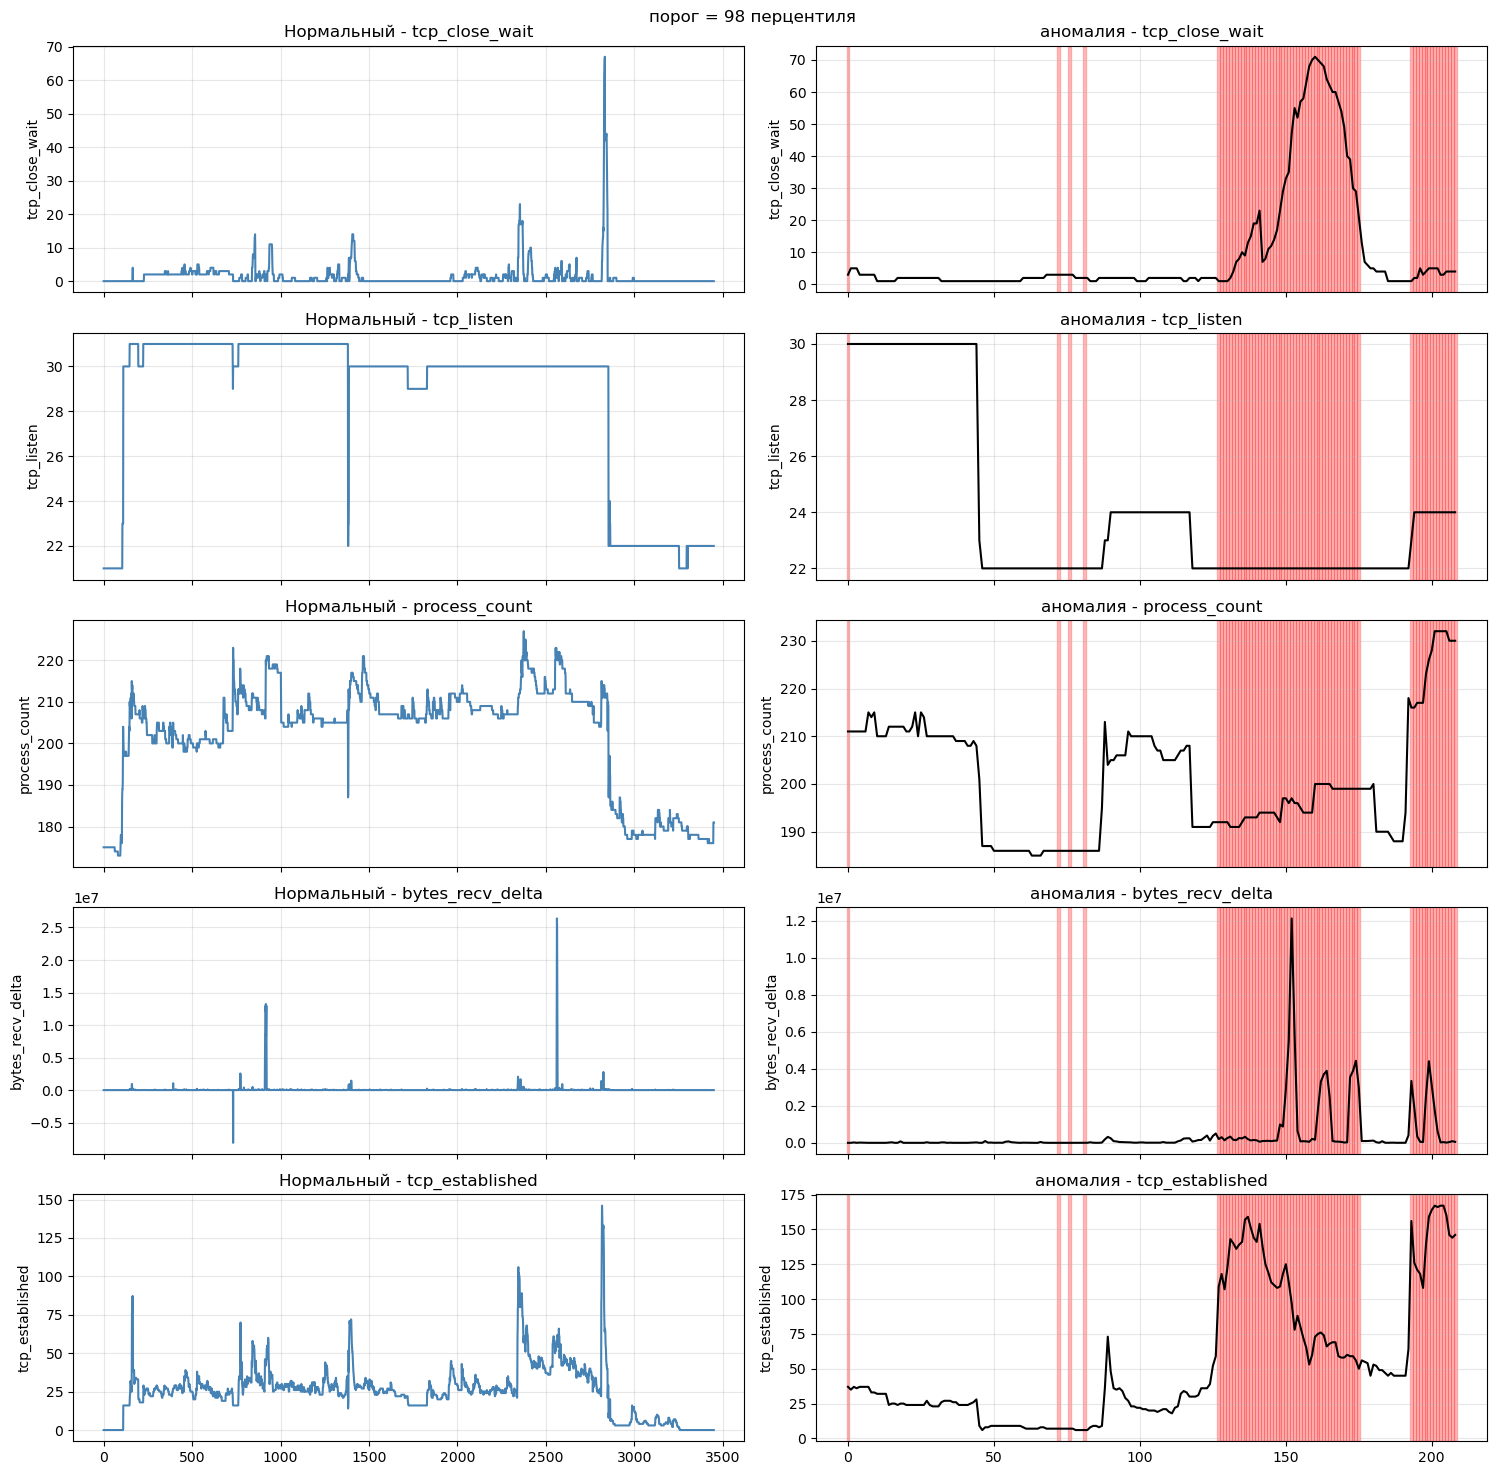

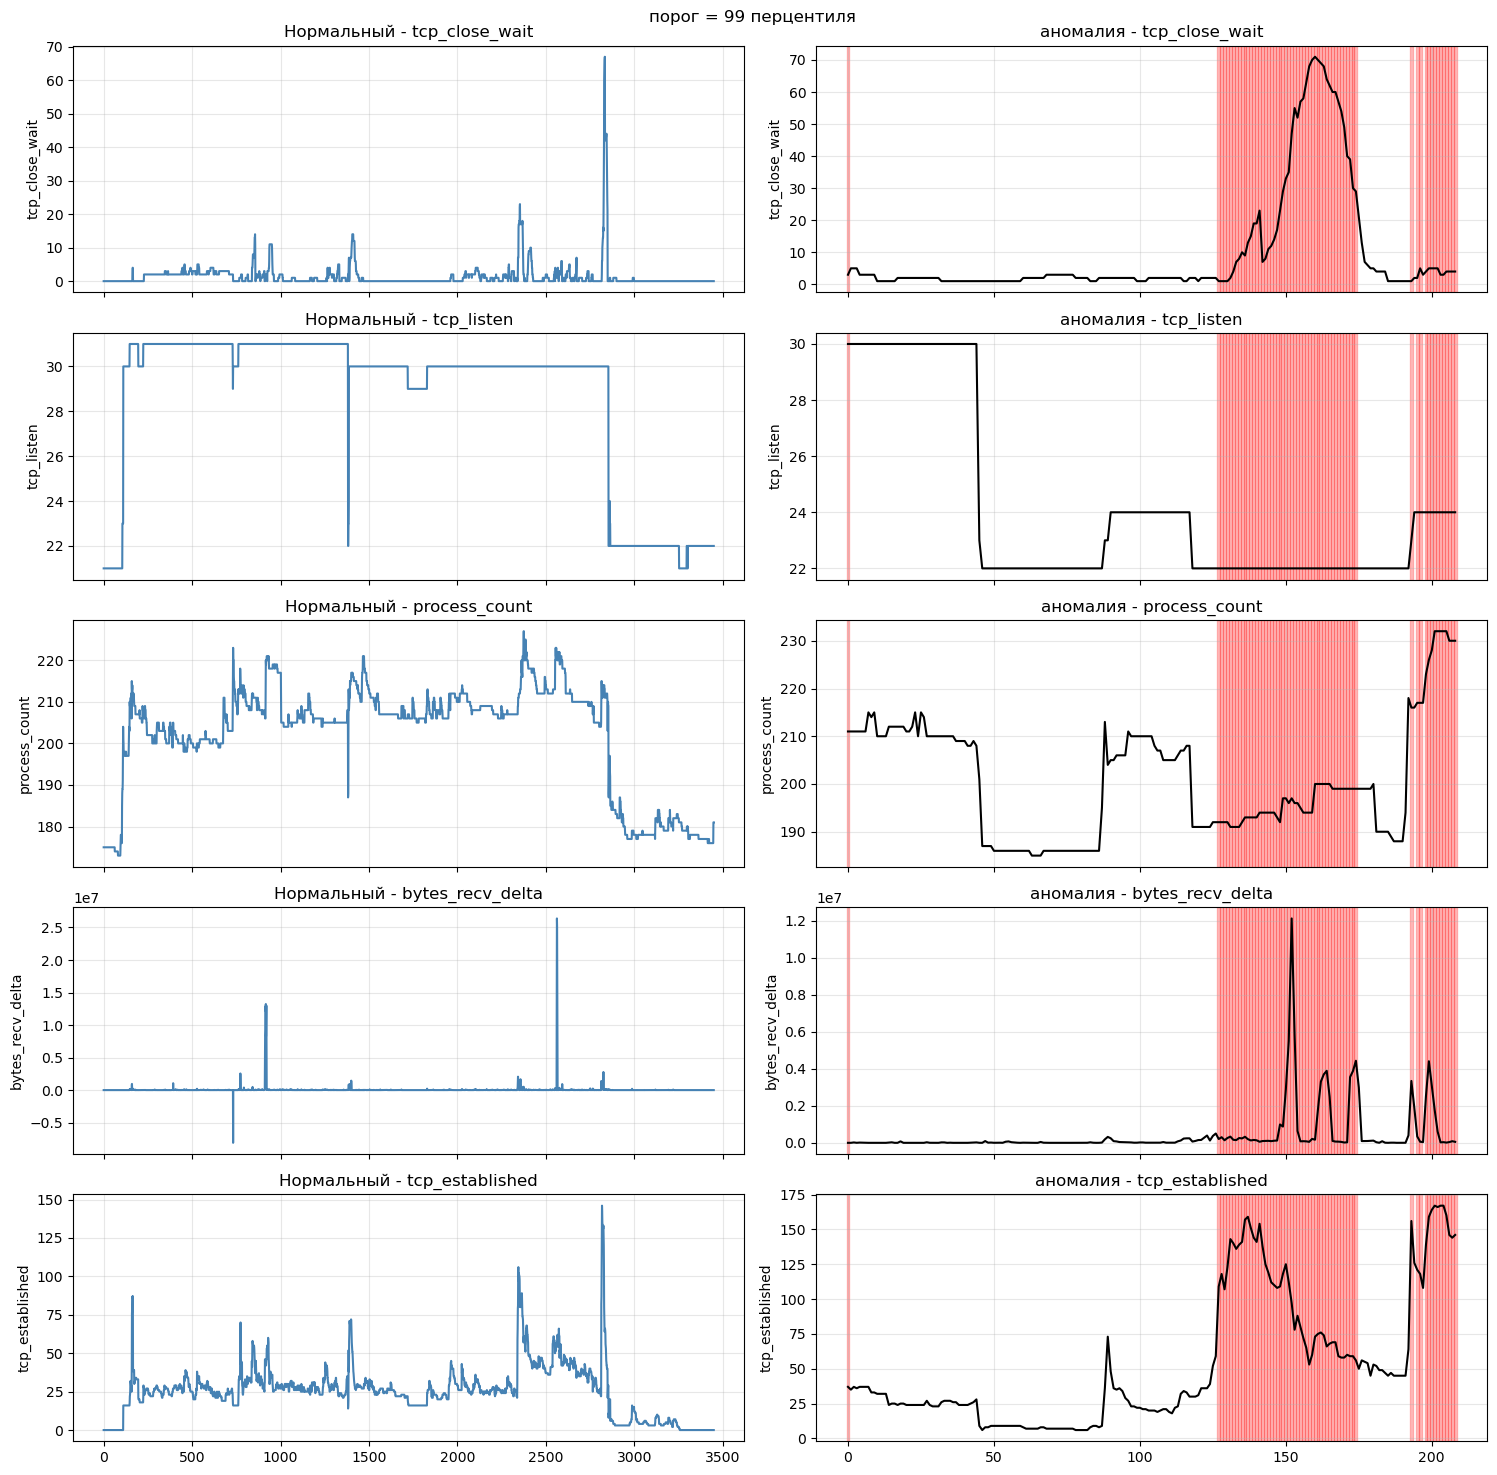

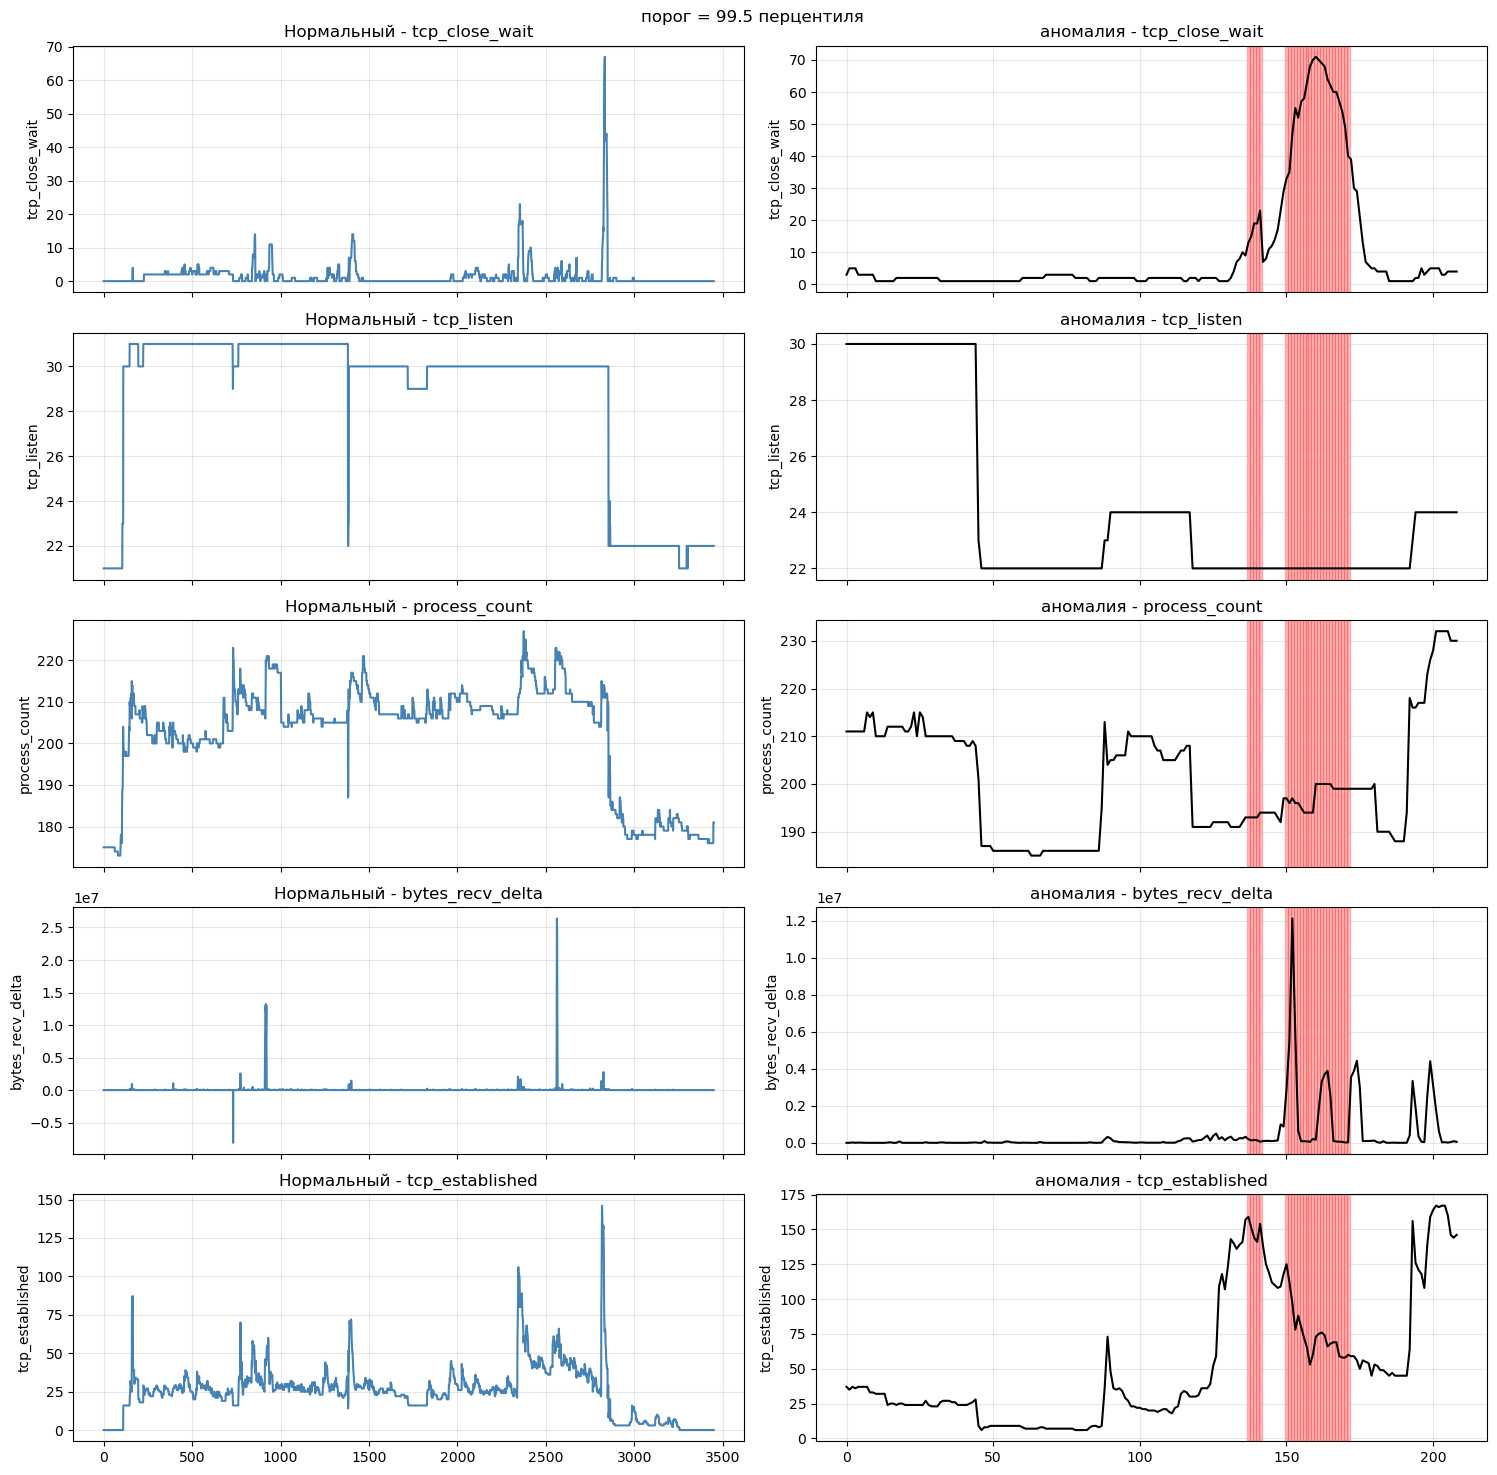

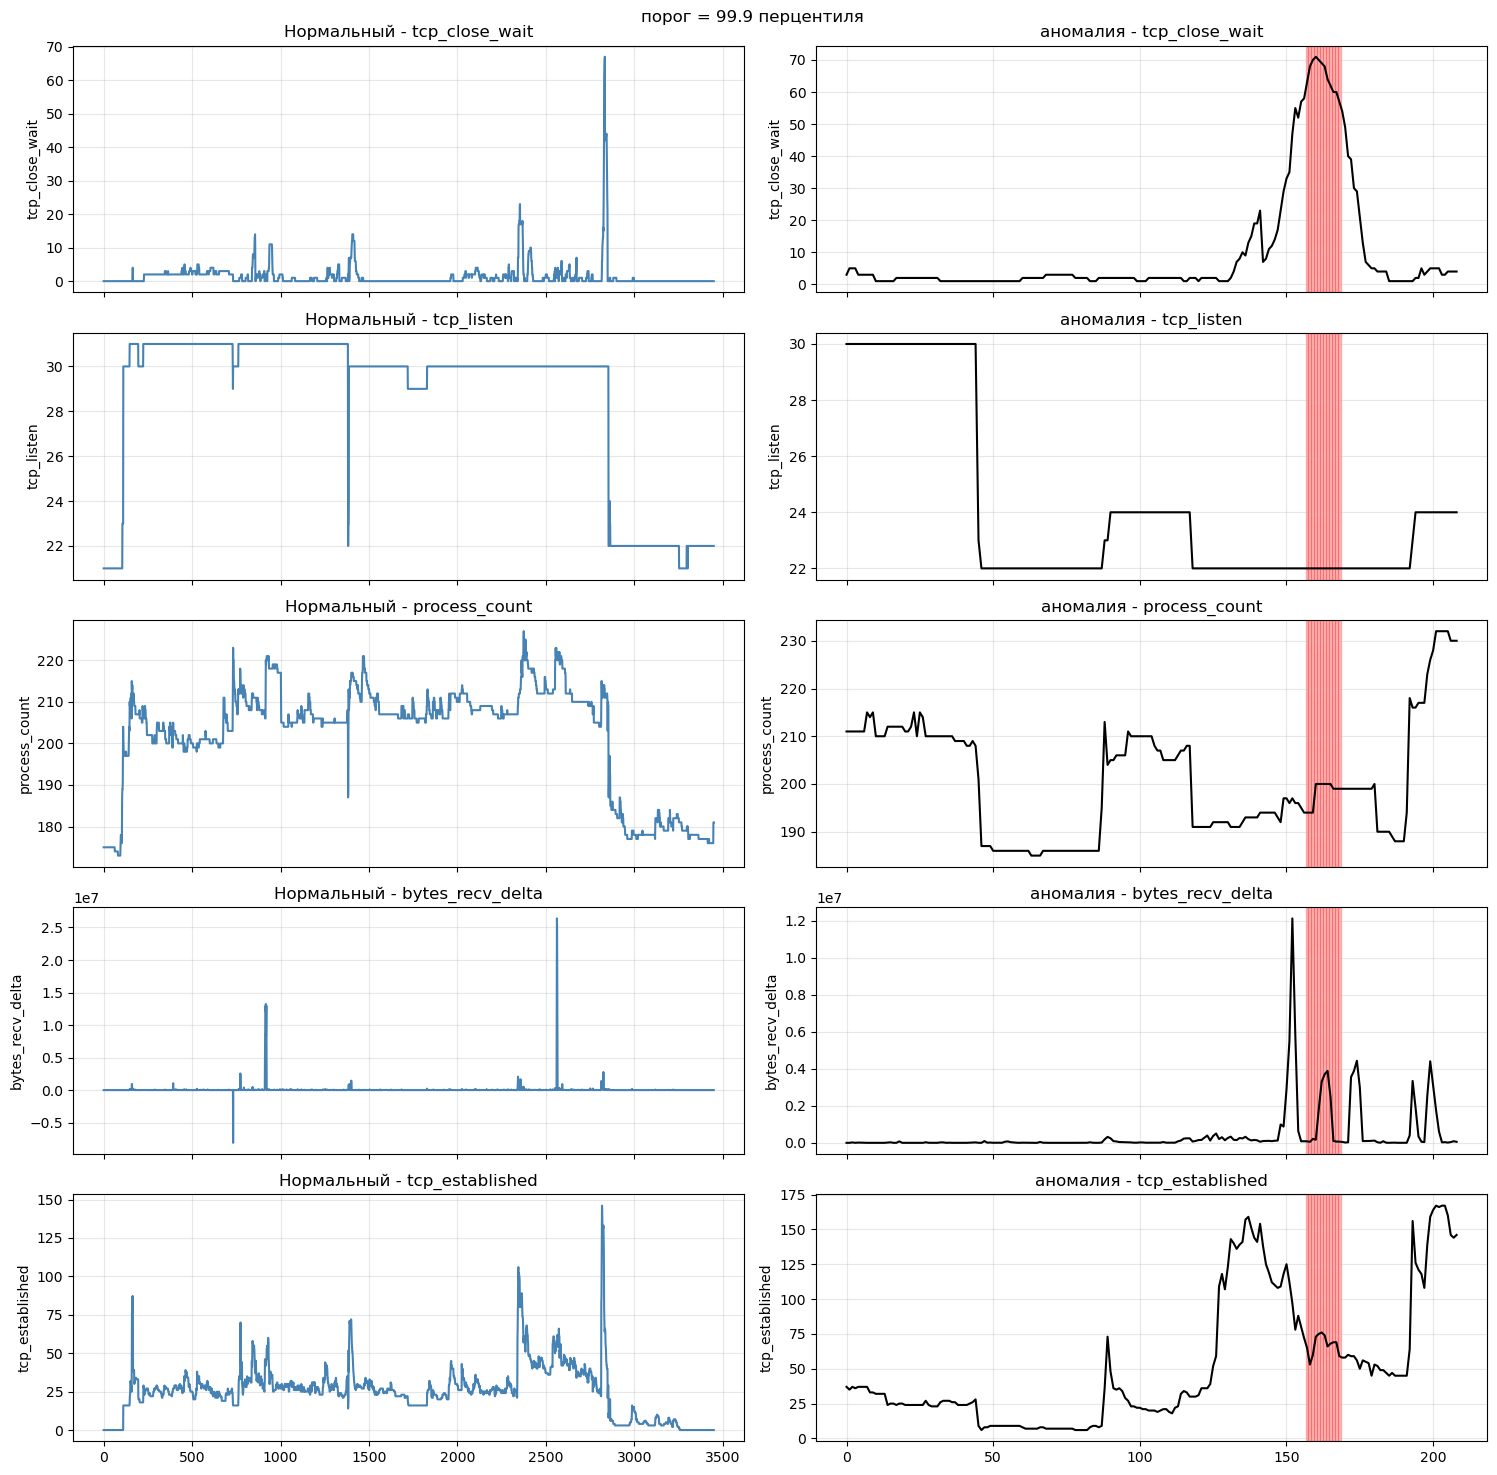

In [20]:
top_features = [
    "tcp_close_wait",
    "tcp_listen",
    "process_count",
    "bytes_recv_delta",
    "tcp_established",
]
for p in [90, 95, 97, 97.5, 98, 99, 99.5, 99.9]:

    show_threshold(
        evaluator=evaluator,
        normal=train_data["val"].reset_index(drop=True),
        anomaly=anomaly.reset_index(drop=True),
        val_loader=train_data["val_loader"],
        anomaly_loader=anomal_loader,
        features=top_features,
        percentile=p
    )

По полученным графиками можно сделать вывод, что с увеличением уровня перцентиля, определяемые объекты (в некотором смысле зоны) как аномальные уменьшается, делая порог более жестким. При этом же низкие уровни более чувствительны к незначительным ошибкам реконструкции, что отражено в остраненных полосах без свое общей зоны покрытия.

Оптимальными в некотором смысле слова, можно считать 
$$
q= 97-98
$$
что покрывают значительную зону неестественного поведения.

Однако, как уже было сказано, низкие уровни перцентиля демонстрировали выскоую чувст-сть к ошибки восстановления моделью. Уровни 97, 98 также не защищены от этого, если прозойдет некот-ый случайный всплеск в системы. Из-за чего, механизм принятия решения по детекции анамалии в виде правила
$$
e_i > t
$$
не эффективен.

Данная проблема является весомой, так как если детектировать такие всплески как аномалией (где после всплеска система будет функционирвоать в штатное режиме), заставляет отрабатывать работу некот-ые и другие системы по обработки аномалиев. Это означает доп-ые затраты в ресурсах, лишней загрузки систем и так далее. Однако, пропустить признак начала "волны" аномалий также не лучший исход. Из-за чего, необходимо рассматривать алгоритмы по принятию решений, который будет учитвать несколько объектов вокруг себя

Алгоритм - __скользящее окно__. 

Данный алгоритм мог бы быть взят как простое решение проблемы, но сущ-ют некот-ые проблемы:
- размер окна
- сдвиг по времени назад на размер окна
- не онлайн

Ключевая проблема - алгоритм не онлайн. Подстраивать можно под вычисления в рельном времени путем сдвига назад по времени на размер окна. Однако такие решения потенциальо замедляют поток инофрмации в раальном времени пропорционально размеру окна

Алгоритм - __экспонициальное накопление__

Данный алгоритм в отличие от свое предщетсвиника работает в онлайн режиме. При этом получаемое значение формируется не сразу как бинарное значение (1/0) для определения аномалии, а как вещественное, которое можно интерпритировать как риск.

Особенность в том, что значение $Risk$ накапливается (увеличивается) в реальном времени, если $e_i$ растет, и наоборот, забывается (уменьшается), если $e_i$ падает

однако рассмотренный алгоритм _экспоненциального накопления_ также не лишен недостатков. При длительной серии больших ошибок $e_i$ значение накопленного $R$ может достигать значительных величин. 

В результате после возвращения системы к адекватному режиму риск начинает уменьшаться слишком медленно, вследствие чего множество последующих наблюдений продолжают ошибочно классифицироваться как аномальные. То есть, алгоритм обладает длительным эффектом памяти, который в рассматриваемой задаче является нежелательным.

По этой причне рассмотрим собственую модификацию, целью кот-ой будет явля-ся:
- снижение влияения единичных экстремальных ошибок восс-ия

- ограничения вклада слишком больших значений ошибок

- усорения захотухания риска, после возращения в ественный режим поведения

- сохранения возмо-сти работы алгоритмы в режиме онлайн

### Экспонициальное накопительная детекция

Базовая модель имеет вид след-ий:
$$
S_t = \alpha S_{t-1} + (1-\alpha)e_t,
$$
где

- $e_t$ - ошибка реконструкции

- $S_t$ - накопленный риск

- $\alpha$ - коэф-ент памяти

#### Модификации

1) Воспользуемся идей пороговой детекции, и будем рассматривать те ошибки, что уже превышают заданный $p$ $$ r_t = \max{(0, e_t-T)}, $$ где T - порог ошибки восстановления.

Таким образом мы не даем риску расти пока идет нормальный режим работы, а значит, нет непредвиденного накопления

2) В процессе вычисления $e_t$ значения ошибко могут вырьироваться как малые ($e_t = 5$), так и большие ($e_t=100$). Таким разбросы в значениях могут привоить к тому, что риск будет увеличиваться мгогократно раз по сравнению с малыми значениям ошибок (в мини-примере выше - в 20 раз). Для приведения к обозримому масштабу, произведем логорифмирование $$ x_t = \log{(1+r_t)}. $$ Таким образом мы увменьшаем влияние крупных выбросов

3) Одна из проблем экспон-ого насыщения по прежнему остается - если значения ошибок увелеичиваются с каждой секундой, или находится около постояннок высоком значении, то риск продолжает расти. Данный эффект является избыточным, так как если значение $e_t$ уже высоко сравнительно граница детекции аномалии, то нет нужды в еще большем риске. Поэтому введем нелинейность в виде зоны насыщения как $$ z_t = \min{(x_t, L)} $$

### Итоговый вид модели

Модель будет записываться как:
$$ r_t = \max{(0, e_t-T)}, $$

$$ x_t = \log{(1+r_t)}. $$

$$ z_t = \min{(x_t, L)} $$

$$ S_t = \alpha S_{t-1} + z_t, $$

$$ \text{ANOMALY}, \space S_t > H $$

## Подбор порогов

### Порог L

Так как после логорифмирования $$ x_t = \log{(1+r_t)}. $$ возможно получение произвольное больших значения $x_t$ вводиться граница как $$ L = \max{(x)}, $$ вычисленная на валидации. И коургляется в меньшую стороны для отсчения высоких значений

In [21]:
def inspect_log_errors(errors, T=0):
    x = np.maximum(0, errors - T)

    print("Ошибки после threshold:")
    display(pd.Series(x).describe().round(4))

    print("\nПосле log1p:")
    display(pd.Series(np.log1p(x)).describe().round(4))

    return x

In [22]:
x = inspect_log_errors(
    errors=evaluator.reconstruction_errors(train_data["val_loader"]),
)

Ошибки после threshold:


count    3451.0000
mean        0.3371
std         2.3735
min         0.0002
25%         0.1177
50%         0.1452
75%         0.1845
max        64.0530
dtype: float64


После log1p:


count    3451.0000
mean        0.1715
std         0.2692
min         0.0002
25%         0.1113
50%         0.1356
75%         0.1693
max         4.1752
dtype: float64

### Коэф-нт затухания

In [23]:
def compare_alpha(
    errors,
    threshold,
    alphas,
):

    r = np.maximum(errors[2700:3000] - threshold, 0)

    x = np.log1p(r)

    fig, ax = plt.subplots(
        2,
        1,
        figsize=(15, 7),
    )

    ax[0].plot(errors[2700:3000], color="black")
    ax[0].axhline(
        threshold,
        color="red",
        ls="--",
        label="пороговая ошибка"
    )

    ax[0].set_ylabel("ошибка восстановления")
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    for alpha in alphas:

        S = np.zeros_like(x)

        for i in range(1, len(x)):
            S[i] = alpha * S[i - 1] + x[i]

        ax[1].plot(
            S,
            lw=2,
            label=f"альфа = {alpha}"
        )

    ax[1].set_ylabel("риск")
    ax[1].set_xlabel("шаг")
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()

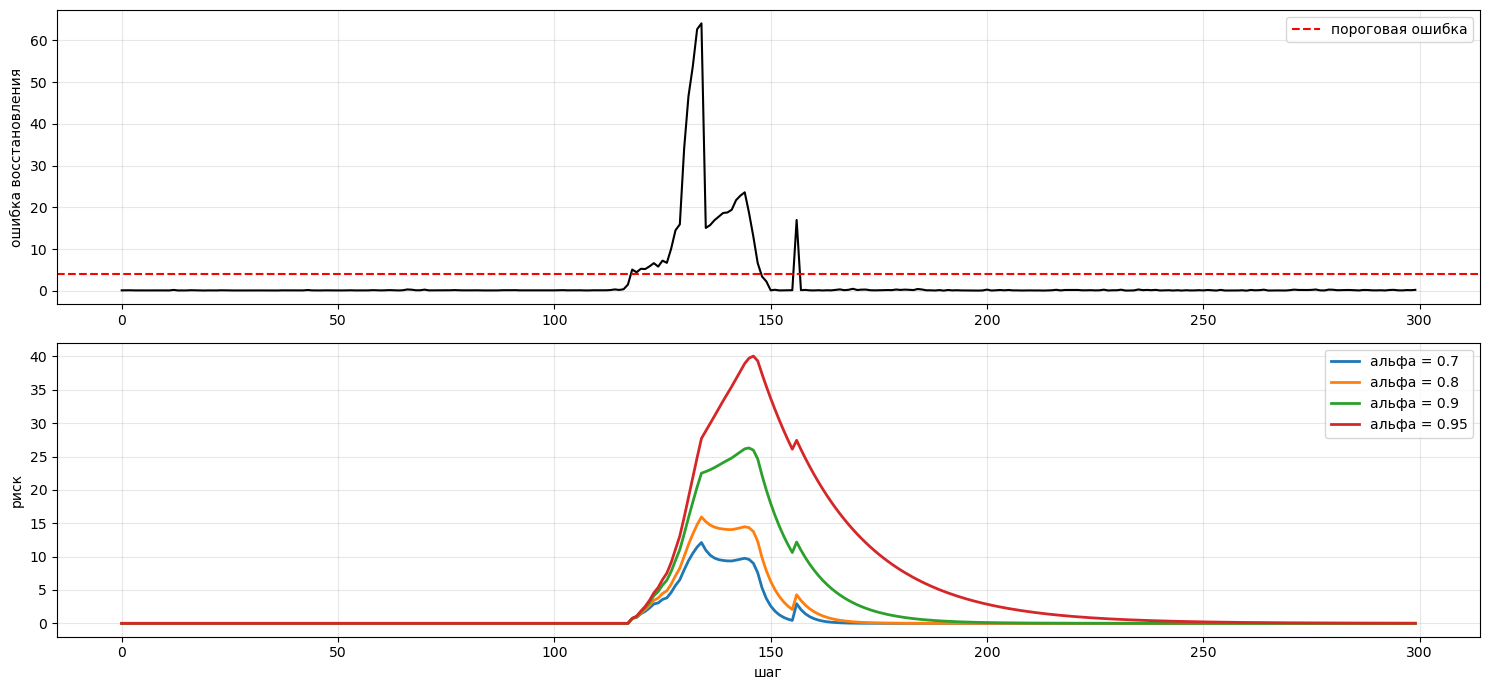

In [30]:
compare_alpha(
    evaluator.reconstruction_errors(train_data["val_loader"]),
    4.0,
    [0.7, 0.8, 0.9, 0.95]
)

Полученные графики изменения риска от коэф-та затухания показыают, что значения при $\alpha = 0.7, 0.95$ явля-ся неудовлеторительными по следующим причинам. 

Значения $\alpha=0.95$ харак-ую малое зыбывание не дает риску умешаться положено быстро после перехода в штатный ежим работы, из за чего присутствует тяжелый хвост. При этом на самом графике ошибок выдно два пика. Для эволюции риска видно, что после прохождения с первого на второй пик риск не успел достаточно уменьшитсья, и лишь подскачил больше.

Значения $\alpha=0.7$ характ-ет быстрое забывание, но при этом виден паттерн соотв-ий двум пикам как на графике ошибок. Однако данное значение может не подходить по причине того, что если аномалии сопровождаются не самыми большими, но частыми последовательными пиками, то риск может недостаточно копиться, из за чего подбор будующего порога H может оказатся более чувствительным

Рассмотрим диапозон значения от 0.8 до 0.9 как интересующий и стабильный

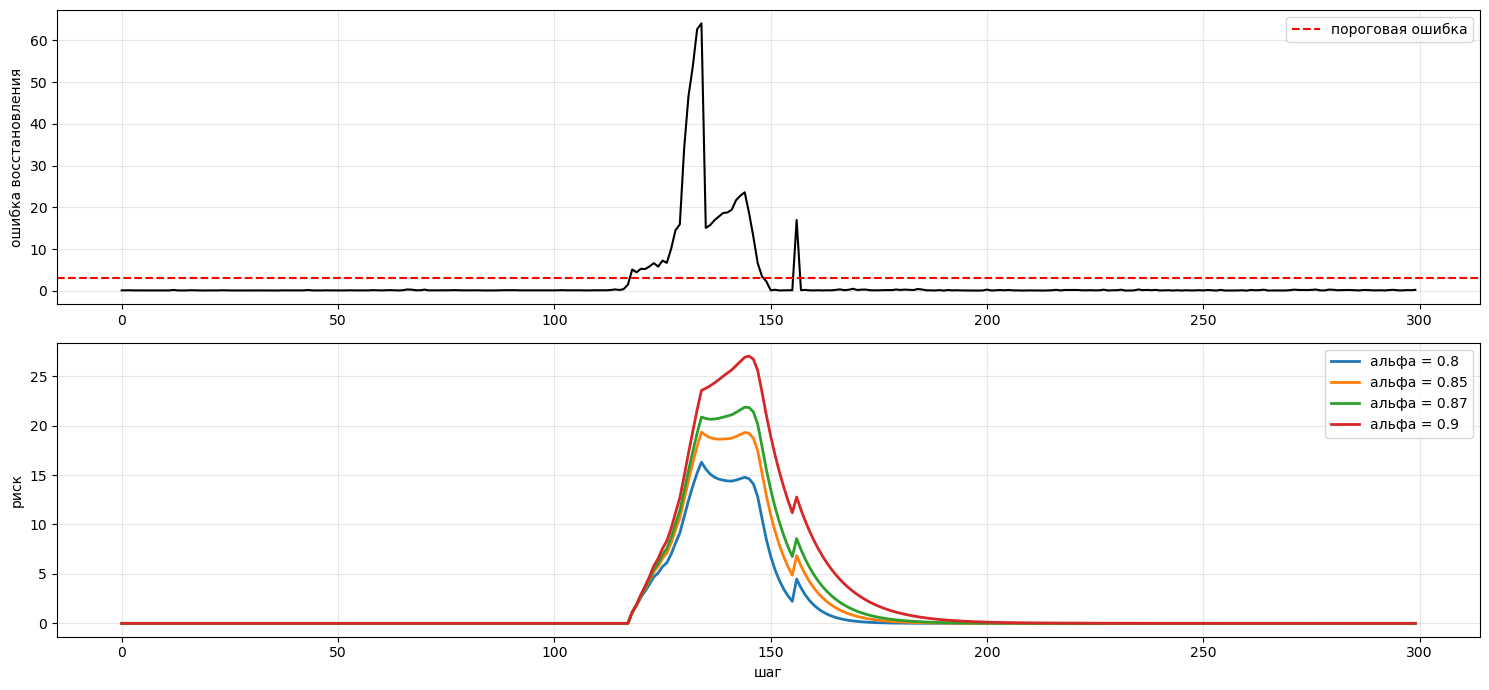

In [ ]:
compare_alpha(
    evaluator.reconstruction_errors(train_data["val_loader"]),
    4.0,
    [0.8, 0.85, 0.87, 0.9]
)

Удовлетворительным оказался $\alpha=0.8$, по следующим причинам:

- сохранение паттерна двух пик

- малая мика дает значительнее скачок чем меньше значение $\alpha$

Остальные значения не удовлетворяют по той причине, что даже после перехода с большого первого пика на второй, значение S растет дальше. И как следствие, отадляет от перехода в штатного, естественного режима.

### Порог H

In [ ]:
def inspect_risk(errors, T, alpha=0.8, L=4.0):

    r = np.maximum(0, errors - T)

    x = np.minimum(np.log1p(r), L)

    S = np.zeros_like(x)

    for i in range(len(x)):
        if i == 0:
            S[i] = x[i]
        else:
            S[i] = alpha * S[i - 1] + x[i]

    print("Накопленный риск S:")
    display(pd.Series(S).describe().round(4))

    print("\nКандидаты для H:")
    display(
        pd.Series({
            "95": np.percentile(S, 95),
            "97": np.percentile(S, 97),
            "97.5": np.percentile(S, 97.5),
            "98": np.percentile(S, 98),
            "99": np.percentile(S, 99),
            "99.5": np.percentile(S, 99.5),
            "99.9": np.percentile(S, 99.9),
        }).round(4)
    )

    plt.figure(figsize=(12, 4))

    sns.lineplot(x=np.arange(len(S)), y=S)

    for q, color in zip([95, 97.5, 98, 99], ['red', 'blue', 'green', 'orange']):
        
        h = np.percentile(S, q)
        plt.axhline(
            h,
            linestyle="--",
            label=f"H {q}% = {h:.2f}",
            color=color
        )

    plt.xlabel("Наблюдение")
    plt.ylabel("Накопленный риск")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return S

Накопленный риск S:


count    3451.0000
mean        0.1464
std         1.2381
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max        16.7046
dtype: float64


Кандидаты для H:


95       0.0463
97       0.3168
97.5     0.6655
98       1.0932
99       4.3174
99.5    12.3717
99.9    15.5551
dtype: float32

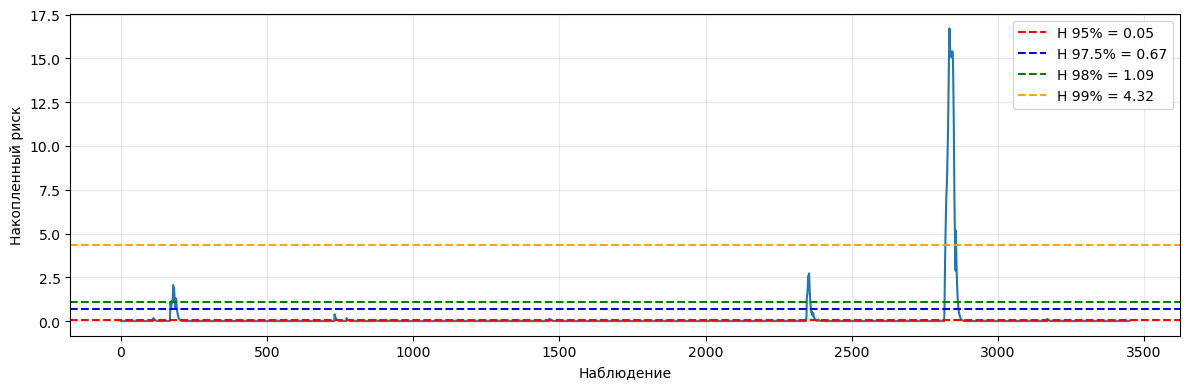

In [31]:
val_errors = evaluator.reconstruction_errors(train_data["val_loader"])

T = np.percentile(val_errors, 97.5)

S = inspect_risk(
    errors=val_errors,
    T=T,
    alpha=0.8,
    L=4.0
)

Порог накопленного риска выбирается как высокий процентиль распределения риска на валидационной выборке. 

Использование 98-го процентиля позволяет получить компромисс между чувствительностью алгоритма и количеством ложных срабатываний. 


Полученное значение H=1.1 округляется до H=1.0, поскольку является статистической оценкой, зависящей от конкретной выборки. 

## Итог работы

In [32]:
def show_exp_accumulation(
    errors,
    signal,
    threshold,
    alpha=0.95,
    alarm_level=1.0,
    title="",
):
    r = np.maximum(errors - threshold, 0)

    x = np.minimum(
        np.log1p(r),
        4.0
    )

    S = np.zeros_like(x)

    for i in range(1, len(x)):
        S[i] = alpha * S[i - 1] + x[i]

    anomaly = S > alarm_level


    fig, ax = plt.subplots(
        3,
        1,
        figsize=(16, 9),
        sharex=True
    )

    ax[0].plot(errors, color="black")
    ax[0].axhline(
        threshold,
        color="red",
        ls="--",
        label="пороговая ошибка"
    )
    ax[0].set_ylabel("ошибка восстановления")
    ax[0].legend()



    ax[1].plot(
        S,
        color="royalblue",
        lw=2,
        label="накопленный риск S"
    )

    ax[1].axhline(
        alarm_level,
        color="red",
        ls="--",
        label="уровень тревоги"
    )

    ax[1].fill_between(
        np.arange(len(S)),
        0,
        S,
        where=anomaly,
        color="red",
        alpha=.25
    )

    ax[1].set_ylabel("S")
    ax[1].legend()


    ax[2].plot(signal, color="black")

    start = None

    for i, flag in enumerate(anomaly):

        if flag and start is None:
            start = i

        elif not flag and start is not None:
            ax[2].axvspan(
                start,
                i,
                color="red",
                alpha=.25
            )
            start = None


    if start is not None:
        ax[2].axvspan(
            start,
            len(signal),
            color="red",
            alpha=.25
        )

    ax[2].set_ylabel("эволюция признака")
    ax[2].set_xlabel("время")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    return S, anomaly

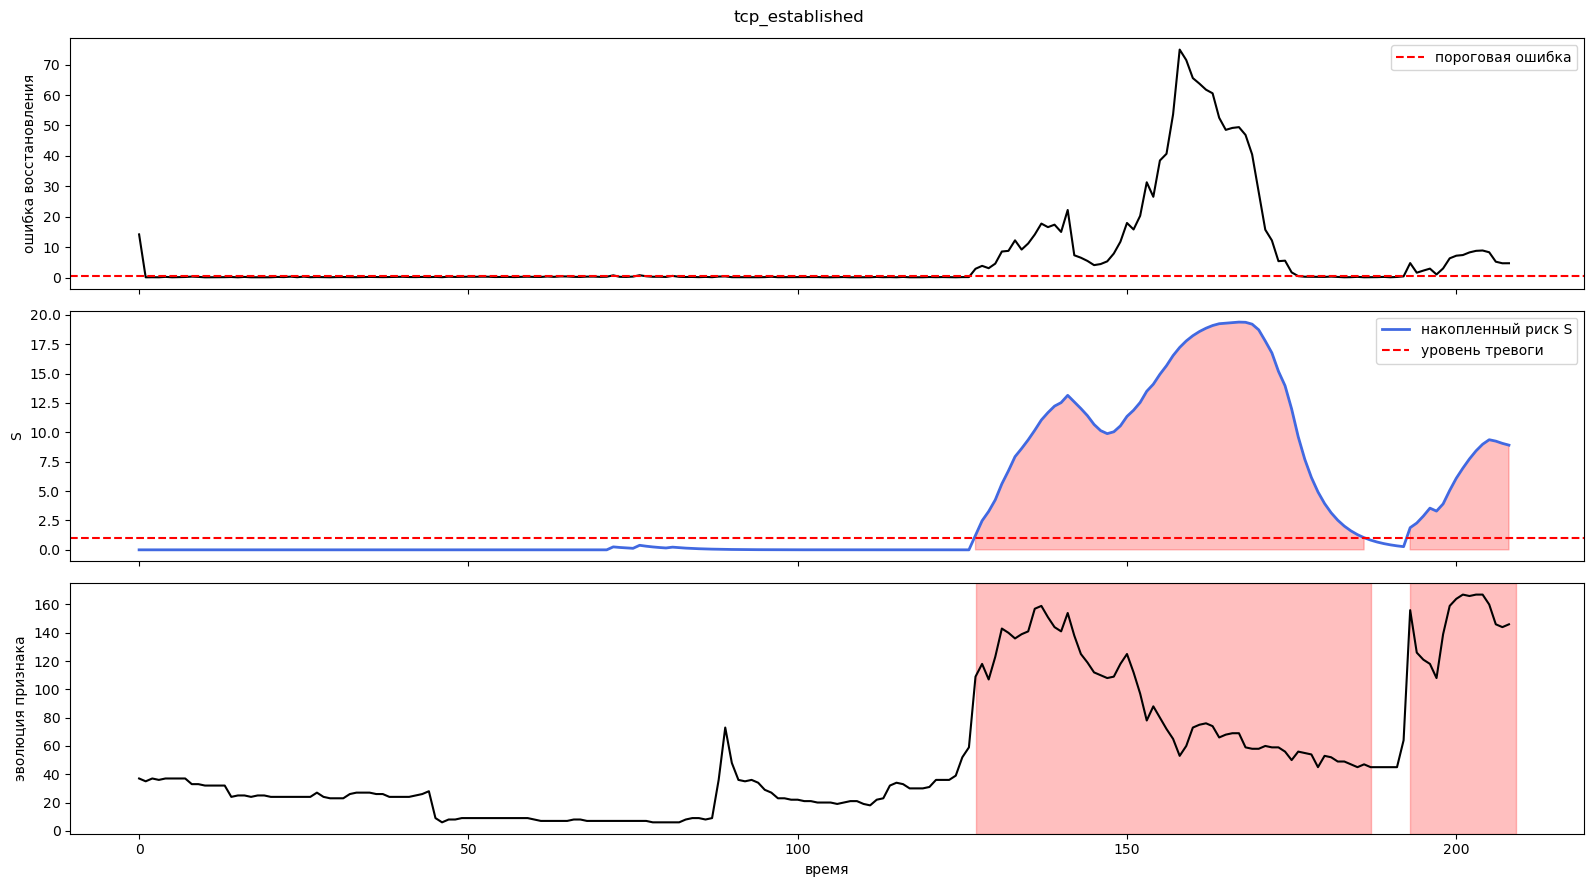

In [34]:
threshold = np.percentile(
    evaluator.reconstruction_errors(train_data["val_loader"]),
    97.5
    )

anom_errors = evaluator.reconstruction_errors(anomal_loader)

S, mask = show_exp_accumulation(
    errors=anom_errors,
    signal=anomaly["tcp_established"].values,
    threshold=threshold,
    alpha=0.8,
    alarm_level=1.0,
    title="tcp_established"
)

График эволюции выбранного признака, ошибки и аккумулироного риска показ-ет, что алгоритм работает эффективнее, чем алгоритм пороговой детекции. При этом модифицированный экспонициальный накопитель работает как детектор с непрерывными числами, давая возможность к более гибком определению порога и настриваемый параметрам

## Итоговый алгоритм и параметры


$$ r_t = \max{(0, e_t-T)}, $$

$$ x_t = \log{(1+r_t)}. $$

$$ z_t = \min{(x_t, L)} $$

$$ S_t = \alpha S_{t-1} + z_t, $$

$$ \text{ANOMALY}, \space S_t > H $$

$$T =  P_{97.5}(val)  $$
$$L = \max{log{(\max{0, e_t - T})}}$$
$$ \alpha = 0.8 $$
$$ H = round_{0.5}(P_{98.0}(val)) $$
$$ round_{0.5} = \frac{round(2x)}{2}